In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!git clone https://github.com/xianggkl/VLU-Net.git
%cd VLU-Net

Cloning into 'VLU-Net'...
remote: Enumerating objects: 186, done.
remote: Counting objects: 100% (186/186), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 186 (delta 67), reused 180 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (186/186), 11.84 MiB | 19.62 MiB/s, done.
Resolving deltas: 100% (67/67), done.
/content/VLU-Net


In [4]:
!pip install -q torch torchvision torchaudio
!pip install -q transformers accelerate timm einops scikit-image pandas
!pip install -q open_clip_torch
!pip install -q lpips
!pip install scikit-video
!pip install pytorch-lightning
!pip install ftfy
!pip install -U bitsandbytes>=0.46.1 accelerate transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 74.0 MB/s eta 0:00:00


In [5]:
import os
import numpy as np
from PIL import Image
import torch
import matplotlib.pyplot as plt

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [7]:
DATASET_ROOT = "/content/VLU-Net/datasets"
CACHE_ROOT = "/content/drive/MyDrive/VLU-Net-V2/datasets_cache"

os.makedirs(DATASET_ROOT, exist_ok=True)

!tar -xf "{CACHE_ROOT}/deblurring_datasets.tar" -C "{DATASET_ROOT}"
!tar -xf "{CACHE_ROOT}/dehazing_datasets.tar" -C "{DATASET_ROOT}"
!tar -xf "{CACHE_ROOT}/denoising_datasets.tar" -C "{DATASET_ROOT}"
!tar -xf "{CACHE_ROOT}/delowlight_datasets.tar" -C "{DATASET_ROOT}"
!tar -xf "{CACHE_ROOT}/deraining_datasets.tar" -C "{DATASET_ROOT}"

print("✓ All datasets extracted")

✓ All datasets extracted


In [ ]:
!jupyter nbconvert --to script /content/VLU-Net/CLIP_degradation_extractor.ipynb

[NbConvertApp] Converting notebook /content/VLU-Net/CLIP_degradation_extractor.ipynb to script
[NbConvertApp] Writing 7222 bytes to /content/VLU-Net/CLIP_degradation_extractor.py


In [8]:
import os
import torch
from torch import nn
import torch.optim as optim
import time
from tqdm import tqdm
import datasets
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from peft import LoraConfig, get_peft_model
from transformers import BitsAndBytesConfig
import open_clip
import torch.nn.utils.rnn as rnn_utils
from argparse import ArgumentParser
from peft import PeftModel
import torchvision.transforms.functional as TF

class CLIP_Adapted_ImageEncoder(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip_model = clip_model

        self.adapter = nn.Sequential(
            nn.Linear(512, 512),
            nn.LayerNorm(512),

            nn.LeakyReLU(),

            nn.Linear(512, 512),
            nn.LayerNorm(512),

            nn.LeakyReLU(),

            nn.Linear(512, 512),
            nn.LayerNorm(512)
        )

    def forward(self, image):
        return self.adapter(self.clip_model.encode_image(image))

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [9]:
class CLIP_Adapted_TextEncoder(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip_model = clip_model
        self.adapter = nn.Sequential(
            nn.Linear(512, 512),
            nn.LayerNorm(512),

            nn.LeakyReLU(),

            nn.Linear(512, 512),
            nn.LayerNorm(512),

            nn.LeakyReLU(),

            nn.Linear(512, 512),
            nn.LayerNorm(512)
        )

    def forward(self, text):
        return self.adapter(self.clip_model.encode_text(text))

class DA_adapter(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        for param in clip_model.parameters():
            param.requires_grad = False
        self.ad_imageEncoder = CLIP_Adapted_ImageEncoder(clip_model=clip_model)
        self.ad_textEncoder = CLIP_Adapted_TextEncoder(clip_model=clip_model)

    def forward(self, image, text):
        image = self.ad_imageEncoder(image)
        text = self.ad_textEncoder(text)
        return image, text

In [33]:
parser = ArgumentParser(description='LDUN')
parser.add_argument('--about', type=str, default='5task')
parser.add_argument('--start_epoch', type=int, default=0, help='epoch number of start training')
parser.add_argument('--end_epoch', type=int, default=100, help='epoch number of end training')
parser.add_argument('--learning_rate', type=float, default=1e-5, help='learning rate')
parser.add_argument('--resume', type=bool, default=False, help='is resume')
parser.add_argument('--group_num', type=int, default=1, help='group number for training')
parser.add_argument('--gpu_list', type=str, default='1', help='gpu index')
parser.add_argument('--checkpoints_dir', type=str, default='/content/drive/MyDrive/VLU-Net-V2/Phase3/CLIP_degradation_extractor/Checkpoint', help='checkpoints dir')
parser.add_argument('--log_dir', type=str, default='log', help='log directory')
parser.add_argument('--ext', type=str, default='.png', help='training data directory')
parser.add_argument('--is_aug', type=bool,default=False, help='is aug')
parser.add_argument('--is_clip_tuning', type=bool,default=False, help='is finetuning clip')
parser.add_argument('--patch_size', type=int, default=128, help='patchsize of input.')

# Noise, Haze, Rain, Blurr, Lowlight
NHRBL = ["./datasets/denoising_datasets/15_train_paths.txt",
 "./datasets/denoising_datasets/25_train_paths.txt",
 "./datasets/denoising_datasets/50_train_paths.txt",
 "./datasets/dehazing_datasets/train_paths.txt",
 "./datasets/deraining_datasets/Rain100L/train_paths.txt",
 "./datasets/deblurring_datasets/GoPro/train_paths.txt",
 "./datasets/delowlight_datasets/LoL/train_paths.txt"]

In [34]:
args = parser.parse_args(args=[])
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = args.gpu_list
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [35]:
!pip install --upgrade torchao

blip2_model_path = "/content/drive/MyDrive/VLU-Net-V2/Phase2/Blip2DegradationCaptionNew/blip2_finetuned_adapter"
print("Loading BLIP‑2 processor and model...")

model_name = "Salesforce/blip2-opt-2.7b"

processor = Blip2Processor.from_pretrained(model_name)
processor.tokenizer.pad_token = processor.tokenizer.eos_token

# bnb_config = BitsAndBytesConfig(load_in_8bit=True)

base_model = Blip2ForConditionalGeneration.from_pretrained(
    model_name,
    # quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto"
)

model_inf = PeftModel.from_pretrained(base_model, blip2_model_path)
model_inf.eval()
model_inf.to(device)
torch.set_grad_enabled(False)

Loading BLIP‑2 processor and model...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [36]:
model, preprocess, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
tokenizer = open_clip.get_tokenizer('ViT-B-32')

model = DA_adapter(model)
model.to(device)
model.eval()

DA_adapter(
  (ad_imageEncoder): CLIP_Adapted_ImageEncoder(
    (clip_model): CLIP(
      (visual): VisionTransformer(
        (patchnorm_pre_ln): Identity()
        (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
        (patch_dropout): Identity()
        (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (transformer): Transformer(
          (resblocks): ModuleList(
            (0-11): 12 x ResidualAttentionBlock(
              (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
              (attn): MultiheadAttention(
                (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
              )
              (ls_1): Identity()
              (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
              (mlp): Sequential(
                (c_fc): Linear(in_features=768, out_features=3072, bias=True)
                (gelu): GELU(approximate='none')
                (c_pro

In [37]:
@torch.inference_mode()
def generate_caption_batch(image_paths, model, processor, device):

    images = [
        Image.open(p).convert("RGB")
        for p in image_paths
    ]

    prompt = "Question: Describe the scene. Answer:"

    inputs = processor(
        images=images,
        text=[prompt] * len(images),
        return_tensors="pt",
        padding=True
    ).to(device)

    generated_ids = model.generate(
            **inputs,
            max_new_tokens=60,
            num_beams=1,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            length_penalty=0.8,
            early_stopping=True,
            eos_token_id=processor.tokenizer.eos_token_id,
            pad_token_id=processor.tokenizer.pad_token_id
        )

    captions = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )

    captions = [
        c.replace(prompt, "").strip()
        for c in captions
    ]

    return captions

In [38]:
BASE_DIR = "/content/VLU-Net/datasets"

def fix_path(p):
    return os.path.join(BASE_DIR, p.replace("./", "").strip())

all_image_paths = []

print("🔍 Building dataset paths...")

for file in tqdm(NHRBL, desc="📂 Dataset Files"):

    with open(file, "r") as f:
        lines = [l.strip() for l in f if l.strip()]

    for line in lines:

        if "," not in line:
            continue

        noisy_path, _ = line.split(",")

        noisy_path = fix_path(noisy_path)

        if os.path.exists(noisy_path):
            all_image_paths.append(noisy_path)

print("\n✅ TOTAL IMAGES:", len(all_image_paths))

🔍 Building dataset paths...


📂 Dataset Files: 100%|██████████| 7/7 [00:00<00:00, 14.72it/s]


✅ TOTAL IMAGES: 90752


In [39]:
BASE_SAVE = "/content/drive/MyDrive/VLU-Net-V2/Phase3/CLIP_degradation_extractor/Captions"

os.makedirs(BASE_SAVE, exist_ok=True)

CSV_PATH   = os.path.join(BASE_SAVE, "captions_dataset.csv")
CACHE_PATH = os.path.join(BASE_SAVE, "captions_cache.pt")
STATE_PATH = os.path.join(BASE_SAVE, "captions_state.pt")

SAVE_EVERY = 1000
BATCH_SIZE = 32

In [40]:
class DatasetManager:
    def __init__(self, csv_path, cache_path, state_path):

        self.csv_path = csv_path
        self.cache_path = cache_path
        self.state_path = state_path

        self.df = pd.DataFrame(columns=["image_path", "caption"])
        self.cache = {}
        self.state = {"processed": set()}

        self._load_all()

    def _load_all(self):

        # CSV
        if os.path.exists(self.csv_path):
            self.df = pd.read_csv(self.csv_path)
            print(f"[CSV] Loaded {len(self.df)} rows")

        # CACHE
        if os.path.exists(self.cache_path):
            self.cache = torch.load(self.cache_path)
            print(f"[CACHE] Loaded {len(self.cache)} items")

        # STATE
        if os.path.exists(self.state_path):
            self.state = torch.load(self.state_path)
            print(f"[STATE] Resumed {len(self.state['processed'])} items")

        # sync CSV → cache
        for _, row in self.df.iterrows():
            self.cache[row["image_path"]] = row["caption"]

    def add_batch(self, batch_data):
        """
        batch_data: list of (path, caption)
        """
        df_new = pd.DataFrame(batch_data, columns=["image_path", "caption"])
        self.df = pd.concat([self.df, df_new], ignore_index=True)

        for p, c in batch_data:
            self.cache[p] = c
            self.state["processed"].add(p)

    def exists(self, path):
        return path in self.cache or path in self.state["processed"]

    def save(self):
        self.df.to_csv(self.csv_path, index=False)
        torch.save(self.cache, self.cache_path)
        torch.save(self.state, self.state_path)

manager = DatasetManager(CSV_PATH, CACHE_PATH, STATE_PATH)

[CSV] Loaded 90752 rows
[CACHE] Loaded 90752 items
[STATE] Resumed 90752 items


In [41]:
remaining_paths = [p for p in all_image_paths if not manager.exists(p)]

print("TOTAL:", len(all_image_paths))
print("REMAINING:", len(remaining_paths))

buffer = []

for i in tqdm(range(0, len(remaining_paths), BATCH_SIZE), desc="🖼️ Captioning"):

    batch_paths = remaining_paths[i:i+BATCH_SIZE]

    captions = generate_caption_batch(
        batch_paths,
        model_inf,
        processor,
        device
    )

    buffer.extend(list(zip(batch_paths, captions)))

    if len(buffer) >= SAVE_EVERY:
        manager.add_batch(buffer)
        buffer.clear()
        manager.save()

        print(f"💾 Saved {len(manager.df)} captions")

TOTAL: 90752
REMAINING: 0


🖼️ Captioning: 0it [00:00, ?it/s]


In [42]:
print("ALL IMAGES:", len(all_image_paths))
print("ALREADY DONE:", len(manager.state["processed"]))
print("TO PROCESS:", len([p for p in all_image_paths if not manager.exists(p)]))

ALL IMAGES: 90752
ALREADY DONE: 90752
TO PROCESS: 0


In [43]:
if len(buffer) > 0:
    manager.add_batch(buffer)
    manager.save()

print("\n🎉 DONE")
print("Total captions:", len(manager.df))


🎉 DONE
Total captions: 90752


In [44]:
clip_model, preprocess, _ = open_clip.create_model_and_transforms(
    'ViT-B-32',
    pretrained='laion2b_s34b_b79k'
)

model = DA_adapter(clip_model).to(device)
model.train()


for name, param in model.named_parameters():
    if "adapter" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable = sum(p.requires_grad for p in model.parameters())
print("Trainable params:", trainable)

Trainable params: 24


In [45]:
class FastDataset(Dataset):
    def __init__(self, image_paths, captions_cache, preprocess):
        self.image_paths = image_paths
        self.captions_cache = captions_cache
        self.preprocess = preprocess

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]

        image = Image.open(path).convert("RGB")
        image = self.preprocess(image)

        caption = self.captions_cache[path]

        return image, caption

In [46]:
captions_cache = torch.load(CACHE_PATH, map_location="cpu")
print("Loaded captions:", len(captions_cache))

train_image_paths = [
    p for p in all_image_paths
    if p in captions_cache
]

print("Train images:", len(train_image_paths))

Loaded captions: 90752
Train images: 90752


In [59]:
dataset = FastDataset(
    train_image_paths,
    captions_cache,
    preprocess
)

train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=12,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)


In [60]:
val_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=12,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)


In [61]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=args.learning_rate,
    betas=(0.9, 0.98),
    weight_decay=0.01
)

criterion = torch.nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss()

temperature = 0.07

In [62]:
start_epoch = args.start_epoch

DRIVE_SAVE_DIR = args.checkpoints_dir

os.makedirs(
    DRIVE_SAVE_DIR,
    exist_ok=True
)

latest_ckpt_path = os.path.join(
    DRIVE_SAVE_DIR,
    "model_latest.pth"
)
best_ckpt_path = os.path.join(
    DRIVE_SAVE_DIR,
    "model_best.pth"
)

def load_checkpoint(ckpt_path):
    print(f"[INFO] Loading checkpoint: {ckpt_path}")
    checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])

    if "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    elif "optimizer" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer"])
    else:
        print("[WARNING] Optimizer state not found in checkpoint.")

    return checkpoint["epoch"] + 1

if os.path.exists(latest_ckpt_path):
    try:
        start_epoch = load_checkpoint(latest_ckpt_path)
        print(f"[INFO] Resume Epoch {start_epoch} from latest")
    except Exception as e:
        print(f"[ERROR] Failed to load latest checkpoint: {e}")
        if os.path.exists(best_ckpt_path):
            try:
                print("[INFO] Attempting to load best checkpoint instead...")
                start_epoch = load_checkpoint(best_ckpt_path)
                print(f"[INFO] Resume Epoch {start_epoch} from best")
            except Exception as e2:
                print(f"[ERROR] Failed to load best checkpoint as well: {e2}")
                print("[INFO] Training From Scratch")
        else:
            print("[INFO] Training From Scratch")
else:
    print("[INFO] Training From Scratch")


[INFO] Loading checkpoint: /content/drive/MyDrive/VLU-Net-V2/Phase3/CLIP_degradation_extractor/Checkpoint/3/model_latest.pth
[ERROR] Failed to load latest checkpoint: PytorchStreamReader failed reading zip archive: failed finding central directory. This is an internal miniz error. If you are seeing this error, there is a high likelihood that your checkpoint file is corrupted. This can happen if the checkpoint was not saved properly, was transferred incorrectly, or the file was modified after saving.
[INFO] Attempting to load best checkpoint instead...
[INFO] Loading checkpoint: /content/drive/MyDrive/VLU-Net-V2/Phase3/CLIP_degradation_extractor/Checkpoint/3/model_best.pth
[INFO] Resume Epoch 38 from best


In [55]:
# =====================================================
# TEST ONE CAPTION + TOKENIZATION
# =====================================================

print("Caption cache loaded:", len(captions_cache))

sample_path = all_image_paths[0]

print("=" * 80)
print("SAMPLE IMAGE PATH:")
print(sample_path)

print("\nBLIP GENERATED CAPTION:")
print(captions_cache[sample_path])

tokens = tokenizer([captions_cache[sample_path]])

print("\nTOKEN TENSOR SHAPE:")
print(tokens.shape)

print("\nTOKEN IDS:")
print(tokens)

print("\nTOKEN IDS (LIST FORMAT):")
print(tokens[0].tolist())

print("=" * 80)

Caption cache loaded: 90752
SAMPLE IMAGE PATH:
/content/VLU-Net/datasets/denoising_datasets/BSD400/noisy15/test_001.png

BLIP GENERATED CAPTION:
This is a bear family in heavy noise conditions.

TOKEN TENSOR SHAPE:
torch.Size([1, 77])

TOKEN IDS:
tensor([[49406,   589,   533,   320,  4298,  1315,   530,  4200,  9307,  5892,
           269, 49407,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0]])

TOKEN IDS (LIST FORMAT):
[49406, 589, 533, 320, 4298, 1315, 530, 4200, 9307, 5892, 269, 49407, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [56]:
try:
    # Re-enable gradient tracking that was turned off during BLIP-2 loading
    torch.set_grad_enabled(True)

    # Get one batch from the training loader to define image_features and text_features
    images, captions = next(iter(train_loader))

    images = images.to(device, non_blocking=True)
    texts = tokenizer(list(captions)).to(device)

    # Ensure model is in training mode to track gradients
    model.train()

    # Perform a forward pass
    image_features, text_features = model(images, texts)

    # Calculate a dummy loss to define the 'loss' variable
    image_features_norm = image_features / image_features.norm(dim=-1, keepdim=True)
    text_features_norm = text_features / text_features.norm(dim=-1, keepdim=True)
    logits = (image_features_norm @ text_features_norm.T) / temperature
    targets = torch.arange(len(images), device=device)
    loss = criterion(logits, targets)

    print("image requires_grad:", image_features.requires_grad)
    print("text requires_grad:", text_features.requires_grad)
    print("loss requires_grad:", loss.requires_grad)
except NameError as e:
    print(f"Error: {e}. Please ensure `train_loader`, `tokenizer`, `model`, `device`, `temperature`, and `criterion` are defined and accessible.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

image requires_grad: True
text requires_grad: True
loss requires_grad: True


In [92]:
import torch
from tqdm import tqdm

# Re-enable gradient tracking
torch.set_grad_enabled(True)

train_losses = []
train_accs = []

val_losses = []
val_accs = []

best_val_acc = 0.0

for epoch in range(start_epoch, args.end_epoch):

    #################################################
    # TRAINING
    #################################################
    model.train()

    epoch_loss = 0.0
    epoch_correct = 0
    epoch_total = 0

    pbar = tqdm(train_loader, desc=f"Train Epoch {epoch}")

    for images, captions in pbar:

        images = images.to(device, non_blocking=True)
        texts = tokenizer(list(captions)).to(device)

        # Forward
        image_features, text_features = model(images, texts)

        image_features = image_features / image_features.norm(
            dim=-1, keepdim=True
        )
        text_features = text_features / text_features.norm(
            dim=-1, keepdim=True
        )

        logits = 100.0 * (image_features @ text_features.T)

        targets = torch.arange(len(images), device=device)

        loss = criterion(logits, targets)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        preds = logits.argmax(dim=1)
        batch_correct = (preds == targets).sum().item()

        epoch_correct += batch_correct
        epoch_total += len(images)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{100 * batch_correct / len(images):.1f}%"
        })

    train_loss = epoch_loss / len(train_loader)
    train_acc = epoch_correct / epoch_total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    #################################################
    # VALIDATION
    #################################################
    model.eval()

    val_epoch_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        pbar_val = tqdm(val_loader, desc=f"Val Epoch {epoch}")

        for images, captions in pbar_val:

            images = images.to(device, non_blocking=True)
            texts = tokenizer(list(captions)).to(device)

            image_features, text_features = model(images, texts)

            image_features = image_features / image_features.norm(
                dim=-1, keepdim=True
            )
            text_features = text_features / text_features.norm(
                dim=-1, keepdim=True
            )

            logits = 100.0 * (image_features @ text_features.T)

            targets = torch.arange(len(images), device=device)

            loss = criterion(logits, targets)

            val_epoch_loss += loss.item()

            preds = logits.argmax(dim=1)

            val_correct += (preds == targets).sum().item()
            val_total += len(images)

            pbar_val.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{100 * (preds == targets).sum().item() / len(images):.1f}%"
            })

    val_loss = val_epoch_loss / len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    #################################################
    # PRINT METRICS
    #################################################
    print(
        f"\nEpoch {epoch} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc : {train_acc*100:.2f}% | "
        f"Val Loss  : {val_loss:.4f} | "
        f"Val Acc   : {val_acc*100:.2f}% | "
    )

    #################################################
    # SAVE LATEST CHECKPOINT
    #################################################
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "train_accs": train_accs,
        "val_losses": val_losses,
        "val_accs": val_accs,
        "best_val_acc": best_val_acc,
    }

    torch.save(checkpoint, latest_ckpt_path)

    #################################################
    # SAVE BEST CHECKPOINT
    #################################################
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        checkpoint["best_val_acc"] = best_val_acc

        torch.save(
            checkpoint,
            "/content/best_model.pt"
        )

        print(
            f"[BEST] New best model saved "
            f"(Val Acc = {best_val_acc*100:.2f}%)"
        )

    print(
        f"[LATEST] Checkpoint saved "
        f"(Epoch {epoch})"
    )

Val Epoch 0: 100%|██████████| 1418/1418 [02:07<00:00, 11.13it/s, loss=1.1149, acc=56.2%]



Epoch 0
Train Loss: 1.7639
Train Acc : 46.35%
Val Loss  : 0.9708
Val Acc   : 65.44%
[BEST] New best model saved (Val Acc = 65.44%)
[LATEST] Checkpoint saved (Epoch 0)


Val Epoch 1: 100%|██████████| 1418/1418 [02:05<00:00, 11.29it/s, loss=0.5250, acc=79.7%]



Epoch 1
Train Loss: 0.8001
Train Acc : 70.44%
Val Loss  : 0.6577
Val Acc   : 74.22%
[BEST] New best model saved (Val Acc = 74.22%)
[LATEST] Checkpoint saved (Epoch 1)


Train Epoch 2:  50%|████▉     | 705/1418 [01:08<01:08, 10.34it/s, loss=0.5708, acc=71.9%]


KeyboardInterrupt: 

In [100]:
import torch
from tqdm import tqdm

# Re-enable gradient tracking
torch.set_grad_enabled(True)

train_losses = []
train_accs = []

val_losses = []
val_accs = []

best_val_acc = 0.0

for epoch in range(start_epoch, args.end_epoch):

    #################################################
    # TRAINING
    #################################################
    model.train()

    epoch_loss = 0.0
    epoch_correct = 0
    epoch_total = 0

    pbar = tqdm(train_loader, desc=f"Train Epoch {epoch}")

    for images, captions in pbar:

        images = images.to(device, non_blocking=True)
        texts = tokenizer(list(captions)).to(device)

        # Forward
        image_features, text_features = model(images, texts)

        image_features = image_features / image_features.norm(
            dim=-1, keepdim=True
        )
        text_features = text_features / text_features.norm(
            dim=-1, keepdim=True
        )

        logits = 100.0 * (image_features @ text_features.T)

        targets = torch.arange(len(images), device=device)

        loss = criterion(logits, targets)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        preds = logits.argmax(dim=1)
        batch_correct = (preds == targets).sum().item()

        epoch_correct += batch_correct
        epoch_total += len(images)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{100 * batch_correct / len(images):.1f}%"
        })

    train_loss = epoch_loss / len(train_loader)
    train_acc = epoch_correct / epoch_total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    #################################################
    # VALIDATION
    #################################################
    model.eval()

    val_epoch_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        pbar_val = tqdm(val_loader, desc=f"Val Epoch {epoch}")

        for images, captions in pbar_val:

            images = images.to(device, non_blocking=True)
            texts = tokenizer(list(captions)).to(device)

            image_features, text_features = model(images, texts)

            image_features = image_features / image_features.norm(
                dim=-1, keepdim=True
            )
            text_features = text_features / text_features.norm(
                dim=-1, keepdim=True
            )

            logits = 100.0 * (image_features @ text_features.T)

            targets = torch.arange(len(images), device=device)

            loss = criterion(logits, targets)

            val_epoch_loss += loss.item()

            preds = logits.argmax(dim=1)

            val_correct += (preds == targets).sum().item()
            val_total += len(images)

            pbar_val.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{100 * (preds == targets).sum().item() / len(images):.1f}%"
            })

    val_loss = val_epoch_loss / len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    #################################################
    # PRINT METRICS
    #################################################
    print(
        f"\nEpoch {epoch} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc : {train_acc*100:.2f}% | "
        f"Val Loss  : {val_loss:.4f} | "
        f"Val Acc   : {val_acc*100:.2f}% | "
    )

    #################################################
    # SAVE LATEST CHECKPOINT
    #################################################
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "train_accs": train_accs,
        "val_losses": val_losses,
        "val_accs": val_accs,
        "best_val_acc": best_val_acc,
    }

    torch.save(checkpoint, latest_ckpt_path)

    #################################################
    # SAVE BEST CHECKPOINT
    #################################################
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        checkpoint["best_val_acc"] = best_val_acc

        torch.save(
            checkpoint,
            "/content/best_model.pt"
        )

        print(
            f"[BEST] New best model saved "
            f"(Val Acc = {best_val_acc*100:.2f}%)"
        )

    print(
        f"[LATEST] Checkpoint saved "
        f"(Epoch {epoch})"
    )

Val Epoch 2: 100%|██████████| 1418/1418 [02:07<00:00, 11.13it/s, loss=0.5926, acc=76.6%]



Epoch 2 | Train Loss: 0.6078 | Train Acc : 75.77% | Val Loss  : 0.5414 | Val Acc   : 77.72% | 
[BEST] New best model saved (Val Acc = 77.72%)
[LATEST] Checkpoint saved (Epoch 2)


Val Epoch 3: 100%|██████████| 1418/1418 [02:06<00:00, 11.21it/s, loss=0.5695, acc=73.4%]



Epoch 3 | Train Loss: 0.5279 | Train Acc : 78.02% | Val Loss  : 0.4884 | Val Acc   : 79.18% | 
[BEST] New best model saved (Val Acc = 79.18%)
[LATEST] Checkpoint saved (Epoch 3)


Val Epoch 4: 100%|██████████| 1418/1418 [02:06<00:00, 11.20it/s, loss=0.4346, acc=79.7%]


...

Val Epoch 30: 100%|██████████| 1418/1418 [02:07<00:00, 11.13it/s, loss=0.0996, acc=93.8%]



Epoch 30 | Train Loss: 0.3375 | Train Acc : 83.38% | Val Loss  : 0.3334 | Val Acc   : 83.39% | 
[LATEST] Checkpoint saved (Epoch 30)


Train Epoch 31:  76%|███████▌  | 1076/1418 [01:44<00:33, 10.28it/s, loss=0.2990, acc=82.8%]Process Process-55:
Process Process-49:
Process Process-56:
Process Process-51:
Process Process-59:
Process Process-54:
Traceback (most recent call last):
Exception ignored in: <generator object tqdm.__iter__ at 0x7e92dfa1c280>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1196, in __iter__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1302, in close
    self.display(pos=0)
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1495, in display
    self.sp(self.__str__() if msg is None else msg)
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 459, in print_status
    fp_write('\r' + s + (' ' * max(last_len[0] - len_s, 0)))
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 453, in fp_write
    fp_flush()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/u

KeyboardInterrupt: 

  File "/usr/lib/python3.12/threading.py", line 1169, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


In [31]:
import torch
from tqdm import tqdm

# Re-enable gradient tracking
torch.set_grad_enabled(True)

train_losses = []
train_accs = []

val_losses = []
val_accs = []

best_val_acc = 0.0

for epoch in range(start_epoch, args.end_epoch):

    #################################################
    # TRAINING
    #################################################
    model.train()

    epoch_loss = 0.0
    epoch_correct = 0
    epoch_total = 0

    pbar = tqdm(train_loader, desc=f"Train Epoch {epoch}")

    for images, captions in pbar:

        images = images.to(device, non_blocking=True)
        texts = tokenizer(list(captions)).to(device)

        # Forward
        image_features, text_features = model(images, texts)

        image_features = image_features / image_features.norm(
            dim=-1, keepdim=True
        )
        text_features = text_features / text_features.norm(
            dim=-1, keepdim=True
        )

        logits = 100.0 * (image_features @ text_features.T)

        targets = torch.arange(len(images), device=device)

        loss = criterion(logits, targets)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        preds = logits.argmax(dim=1)
        batch_correct = (preds == targets).sum().item()

        epoch_correct += batch_correct
        epoch_total += len(images)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{100 * batch_correct / len(images):.1f}%"
        })

    train_loss = epoch_loss / len(train_loader)
    train_acc = epoch_correct / epoch_total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    #################################################
    # VALIDATION
    #################################################
    model.eval()

    val_epoch_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        pbar_val = tqdm(val_loader, desc=f"Val Epoch {epoch}")

        for images, captions in pbar_val:

            images = images.to(device, non_blocking=True)
            texts = tokenizer(list(captions)).to(device)

            image_features, text_features = model(images, texts)

            image_features = image_features / image_features.norm(
                dim=-1, keepdim=True
            )
            text_features = text_features / text_features.norm(
                dim=-1, keepdim=True
            )

            logits = 100.0 * (image_features @ text_features.T)

            targets = torch.arange(len(images), device=device)

            loss = criterion(logits, targets)

            val_epoch_loss += loss.item()

            preds = logits.argmax(dim=1)

            val_correct += (preds == targets).sum().item()
            val_total += len(images)

            pbar_val.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{100 * (preds == targets).sum().item() / len(images):.1f}%"
            })

    val_loss = val_epoch_loss / len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    #################################################
    # PRINT METRICS
    #################################################
    print(
        f"\nEpoch {epoch} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc : {train_acc*100:.2f}% | "
        f"Val Loss  : {val_loss:.4f} | "
        f"Val Acc   : {val_acc*100:.2f}% | "
    )

    #################################################
    # SAVE LATEST CHECKPOINT
    #################################################
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "train_accs": train_accs,
        "val_losses": val_losses,
        "val_accs": val_accs,
        "best_val_acc": best_val_acc,
    }

    torch.save(checkpoint, latest_ckpt_path)

    #################################################
    # SAVE BEST CHECKPOINT
    #################################################
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        checkpoint["best_val_acc"] = best_val_acc

        torch.save(checkpoint, best_ckpt_path)

        print(
            f"[BEST] New best model saved "
            f"(Val Acc = {best_val_acc*100:.2f}%)"
        )

    print(
        f"[LATEST] Checkpoint saved "
        f"(Epoch {epoch})"
    )

Val Epoch 30: 100%|██████████| 1418/1418 [02:05<00:00, 11.33it/s, loss=0.3869, acc=82.8%]



Epoch 30 | Train Loss: 0.3372 | Train Acc : 83.36% | Val Loss  : 0.3375 | Val Acc   : 83.34% | 
[BEST] New best model saved (Val Acc = 83.34%)
[LATEST] Checkpoint saved (Epoch 30)


Val Epoch 31: 100%|██████████| 1418/1418 [02:05<00:00, 11.32it/s, loss=0.3376, acc=78.1%]



Epoch 31 | Train Loss: 0.3387 | Train Acc : 83.33% | Val Loss  : 0.3351 | Val Acc   : 83.38% | 
[BEST] New best model saved (Val Acc = 83.38%)
[LATEST] Checkpoint saved (Epoch 31)


Val Epoch 32: 100%|██████████| 1418/1418 [02:06<00:00, 11.19it/s, loss=0.4152, acc=78.1%]


...


Epoch 41 | Train Loss: 0.3311 | Train Acc : 83.48% | Val Loss  : 0.3262 | Val Acc   : 83.63% | 
[LATEST] Checkpoint saved (Epoch 41)


Val Epoch 42: 100%|██████████| 1418/1418 [02:07<00:00, 11.09it/s, loss=0.2441, acc=89.1%]



Epoch 42 | Train Loss: 0.3295 | Train Acc : 83.56% | Val Loss  : 0.3267 | Val Acc   : 83.59% | 
[LATEST] Checkpoint saved (Epoch 42)


Train Epoch 43:   1%|          | 14/1418 [00:03<05:16,  4.44it/s, loss=0.2326, acc=85.9%]


KeyboardInterrupt: 

In [63]:
import torch
from tqdm import tqdm

# Re-enable gradient tracking
torch.set_grad_enabled(True)

train_losses = []
train_accs = []

val_losses = []
val_accs = []

best_val_acc = 0.0

for epoch in range(start_epoch, args.end_epoch):

    #################################################
    # TRAINING
    #################################################
    model.train()

    epoch_loss = 0.0
    epoch_correct = 0
    epoch_total = 0

    pbar = tqdm(train_loader, desc=f"Train Epoch {epoch}")

    for images, captions in pbar:

        images = images.to(device, non_blocking=True)
        texts = tokenizer(list(captions)).to(device)

        # Forward
        image_features, text_features = model(images, texts)

        image_features = image_features / image_features.norm(
            dim=-1, keepdim=True
        )
        text_features = text_features / text_features.norm(
            dim=-1, keepdim=True
        )

        logits = 100.0 * (image_features @ text_features.T)

        targets = torch.arange(len(images), device=device)

        loss = criterion(logits, targets)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        preds = logits.argmax(dim=1)
        batch_correct = (preds == targets).sum().item()

        epoch_correct += batch_correct
        epoch_total += len(images)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{100 * batch_correct / len(images):.1f}%"
        })

    train_loss = epoch_loss / len(train_loader)
    train_acc = epoch_correct / epoch_total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    #################################################
    # VALIDATION
    #################################################
    model.eval()

    val_epoch_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        pbar_val = tqdm(val_loader, desc=f"Val Epoch {epoch}")

        for images, captions in pbar_val:

            images = images.to(device, non_blocking=True)
            texts = tokenizer(list(captions)).to(device)

            image_features, text_features = model(images, texts)

            image_features = image_features / image_features.norm(
                dim=-1, keepdim=True
            )
            text_features = text_features / text_features.norm(
                dim=-1, keepdim=True
            )

            logits = 100.0 * (image_features @ text_features.T)

            targets = torch.arange(len(images), device=device)

            loss = criterion(logits, targets)

            val_epoch_loss += loss.item()

            preds = logits.argmax(dim=1)

            val_correct += (preds == targets).sum().item()
            val_total += len(images)

            pbar_val.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{100 * (preds == targets).sum().item() / len(images):.1f}%"
            })

    val_loss = val_epoch_loss / len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    #################################################
    # PRINT METRICS
    #################################################
    print(
        f"\nEpoch {epoch} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc : {train_acc*100:.2f}% | "
        f"Val Loss  : {val_loss:.4f} | "
        f"Val Acc   : {val_acc*100:.2f}% | "
    )

    learnable_params = {
        name: param.detach().cpu()
        for name, param in model.named_parameters()
        if param.requires_grad
    }

    #################################################
    # SAVE LATEST CHECKPOINT
    #################################################
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "learnable_params": learnable_params,
        "train_losses": train_losses,
        "train_accs": train_accs,
        "val_losses": val_losses,
        "val_accs": val_accs,
        "best_val_acc": best_val_acc,
    }

    torch.save(checkpoint, latest_ckpt_path)

    #################################################
    # SAVE BEST CHECKPOINT
    #################################################
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        checkpoint["best_val_acc"] = best_val_acc

        torch.save(checkpoint, best_ckpt_path)

        print(
            f"[BEST] New best model saved "
            f"(Val Acc = {best_val_acc*100:.2f}%)"
        )

    print(
        f"[LATEST] Checkpoint saved "
        f"(Epoch {epoch})"
    )

Val Epoch 38: 100%|██████████| 1418/1418 [02:08<00:00, 11.06it/s, loss=0.4038, acc=78.1%]



Epoch 38 | Train Loss: 0.3319 | Train Acc : 83.52% | Val Loss  : 0.3284 | Val Acc   : 83.67% | 
[BEST] New best model saved (Val Acc = 83.67%)
[LATEST] Checkpoint saved (Epoch 38)


Val Epoch 39: 100%|██████████| 1418/1418 [02:06<00:00, 11.23it/s, loss=0.2578, acc=87.5%]



Epoch 39 | Train Loss: 0.3308 | Train Acc : 83.56% | Val Loss  : 0.3277 | Val Acc   : 83.59% | 
[LATEST] Checkpoint saved (Epoch 39)


Val Epoch 40: 100%|██████████| 1418/1418 [02:06<00:00, 11.20it/s, loss=0.3937, acc=78.1%]


...


Epoch 97 | Train Loss: 0.3131 | Train Acc : 83.95% | Val Loss  : 0.3111 | Val Acc   : 84.04% | 
[LATEST] Checkpoint saved (Epoch 97)


Val Epoch 98: 100%|██████████| 1418/1418 [02:07<00:00, 11.14it/s, loss=0.2977, acc=84.4%]



Epoch 98 | Train Loss: 0.3119 | Train Acc : 84.03% | Val Loss  : 0.3099 | Val Acc   : 84.07% | 
[LATEST] Checkpoint saved (Epoch 98)


Val Epoch 99: 100%|██████████| 1418/1418 [02:07<00:00, 11.15it/s, loss=0.4342, acc=75.0%]



Epoch 99 | Train Loss: 0.3131 | Train Acc : 83.94% | Val Loss  : 0.3120 | Val Acc   : 84.02% | 
[LATEST] Checkpoint saved (Epoch 99)


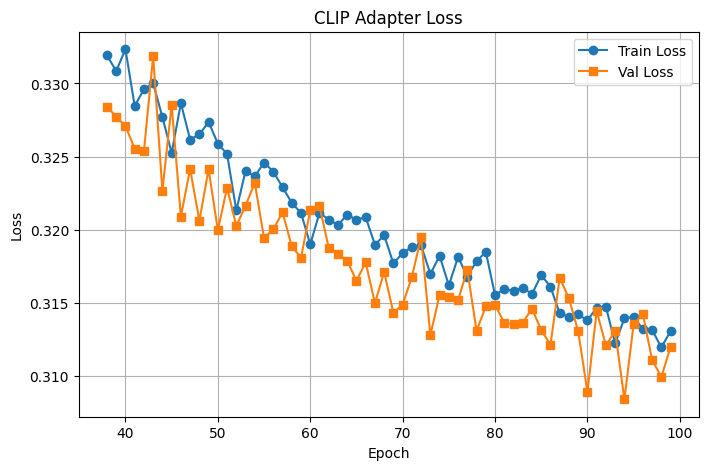

In [64]:
epochs = range(start_epoch, start_epoch + len(train_losses))

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker='o',
    label='Train Loss'
)

plt.plot(
    epochs,
    val_losses,
    marker='s',
    label='Val Loss'
)

plt.title("CLIP Adapter Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

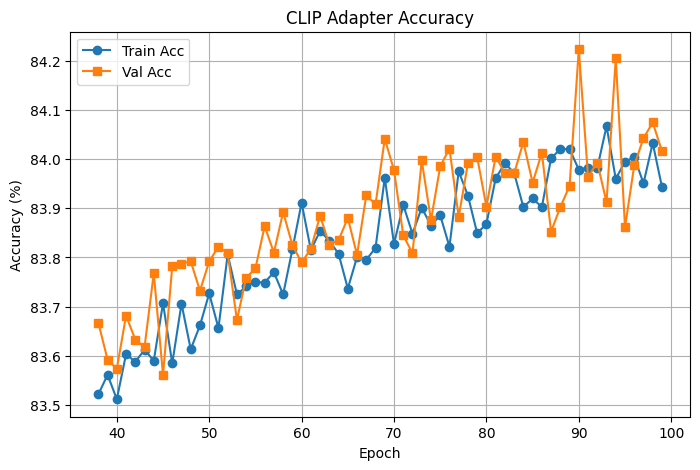

In [65]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [x * 100 for x in train_accs],
    marker='o',
    label='Train Acc'
)

plt.plot(
    epochs,
    [x * 100 for x in val_accs],
    marker='s',
    label='Val Acc'
)

plt.title("CLIP Adapter Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.show()